# **GEOM90006 Assignment 4 Major Project** 

## **Topic: Modelling Changes in Phytoplankton Concentrations in the North Sea**

#### **Authors:** Kadhum Ashir, Warattaya Juntorn, Thomas Maltby

### **Introduction** 

Phytoplankton are microscopic marine organisms that form the foundation of ocean food webs and play a critical role in global biogeochemical cycles. Through photosynthesis, phytoplankton contribute substantially to marine primary productivity and oxygen production, making them essential to both marine ecosystems and climate regulation (Falkowski, 1994). Chlorophyll-a concentration is widely used as an indicator of phytoplankton abundance and productivity and can be monitored using satellite-based remote sensing data (Boyer et al., 2009).

The North Sea is one of the most intensively used marine regions in the world, supporting extensive offshore oil and gas extraction, commercial shipping, and coastal development. In addition to anthropogenic activities, environmental factors such as sea surface temperature, nutrient availability, and seasonal variability can influence phytoplankton distribution and productivity (Alvarez-Fernandez et al., 2012). Understanding how these factors interact is important for assessing ecosystem health and potential environmental impacts within the region.

This study investigates the spatial and temporal distribution of surface chlorophyll-a concentrations in the North Sea during 2025. Using chlorophyll-a raster data, offshore oil well locations, coastline data, and spatial analysis techniques, the project aims to explore relationships between phytoplankton concentration, coastal proximity, and human activities. The findings will contribute to a better understanding of environmental drivers of phytoplankton variability and support discussions related to marine sustainability, ecosystem resilience, and future environmental management.


## 1.0 Topic & Research Question
This project examines the various impacts of factors such as ocean temperature, oil field placement and proximity to coastal areas on the density of phytoplankton, as measured by the concentration of chlorophyll-a in sea water. We then plan to use this correlation to model future changes in phytoplankton concentrations in the face of climate change and future oil developments.
### **Research Question:**
#### *How do sea surface temperature, coastal proximity, and offshore oil infrastructure influence surface chlorophyll-a concentrations in the North Sea?*

## 2.0 Scope of the Project
### 2.1 Spatial, elevation, and temporal scope:
The study focuses on the North Sea between the UK, the north of Germany, and Norway. Figure 1 shows the general area that will be focussed on.
Spatial scale: Latitude 52-62, Longitude -4-9
Elevation extent: Sea level
Data type and time scale: Data timesteps taken from each month over 2025, applied to future timeframes.

### 2.2 Input Data Scope
The input data will aim to include all major geospatial influences on phytoplankton populations to produce a useful model.

### 2.3 Modelling Scope
The model will be used to predict changes in phytoplankton concentration due to rising ocean temperature and oil field developments, and ocean traffic.

## 3.0 Proposed Data Sources
### 3.1 Point Data
North sea transition authority UKCS offshore petroleum exploration and appraisal wellbore results (NSTA, 2025)

### 3.2 Polygon Data
Coastline data (Natural Earth dataset)

### 3.3 Raster Data
Most if not all raster data will be from Copernicus’ open access database. They use a range of data sources including the Sentinel-3 satellite for ocean rasters. Their database will be used for a range of relevant rasters such as chlorophyll-a concentrations and ocean temperature models.
EMODnet Human Activities may also be used to find raster data on human ocean traffic.


## 4.0 Your Task

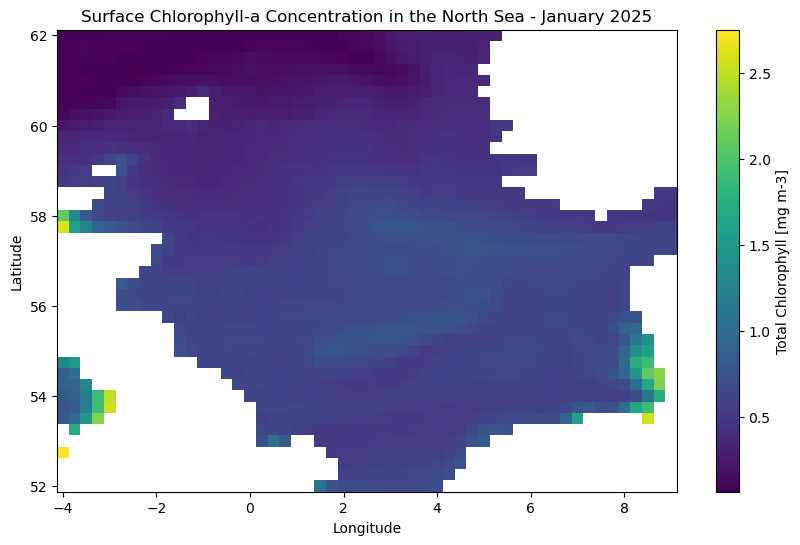

In [1]:
#Chla conc. North Sea in Jan 2025
import xarray as xr

data = xr.open_dataset("./chla_2025/mercatorbiomer4v2r1_global_mean_pft_202501.nc")
import matplotlib.pyplot as plt

# Select surface chlorophyll-a from the first month
surface_chl = data['chl'].isel(time=0, depth=0)

# Clip to North Sea area
north_sea_chl = surface_chl.sel(
    longitude=slice(-4, 9),
    latitude=slice(52, 62)
)

# Plot map
north_sea_chl.plot(figsize=(10, 6), cmap="viridis")

plt.title("Surface Chlorophyll-a Concentration in the North Sea - January 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Figure 1.** *Spatial distribution of surface chlorophyll-a concentration in the North Sea during January 2025.*

Higher chlorophyll-a concentrations were mainly found near coastal regions, likely due to higher nutrient inputs from rivers and coastal mixing, which support phytoplankton growth. 

In contrast, offshore areas showed lower chlorophyll-a levels, possibly due to lower nutrient availability and more stable ocean conditions. 

These patterns are consistent with previous studies linking phytoplankton distribution to nutrient availability and environmental conditions (Boyer et al., 2009).

This pattern may show differences in nutrient levels, ocean currents, and environmental conditions across the study area.

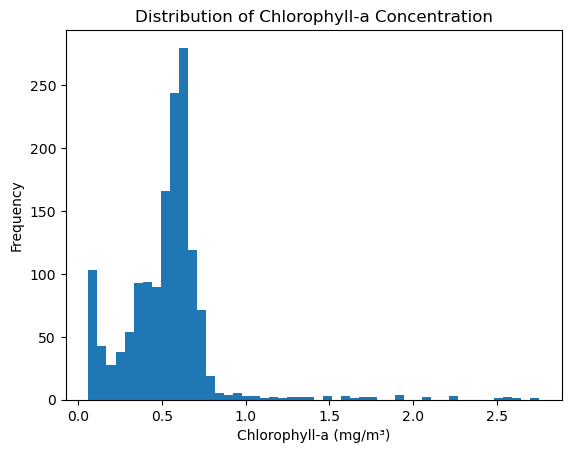

In [2]:
north_sea_chl.plot.hist(bins=50)

plt.title("Distribution of Chlorophyll-a Concentration")
plt.xlabel("Chlorophyll-a (mg/m³)")
plt.ylabel("Frequency")

plt.show()

**Figure 2.** *Distribution of Surface Chlorophyll-a Concentration in the North Sea during January 2025*

The histogram shows that most chlorophyll-a levels in the North Sea in January 2025 were mostly low to moderate, with fewer areas having much higher levels. This uneven pattern suggests that phytoplankton amounts were generally moderate in most places, with some local spots possibly showing more biological activity or phytoplankton blooms.

The relatively lower chlorophyll-a levels seen across much of the North Sea may also be due to winter conditions in the Northern Hemisphere. Less sunlight and colder sea surface temperatures during winter can slow down the growth of tiny water plants and reduce overall productivity (Alvarez-Fernandez et al., 2012). However, some local areas with higher chlorophyll-a levels may show places with good nutrients, coastal water mixing, or other ocean conditions that help these plants grow.

Seasonal variability in phytoplankton concentration has previously been observed in the North Sea, including distinct spring bloom events associated with changing environmental conditions (Silori et al., 2025).

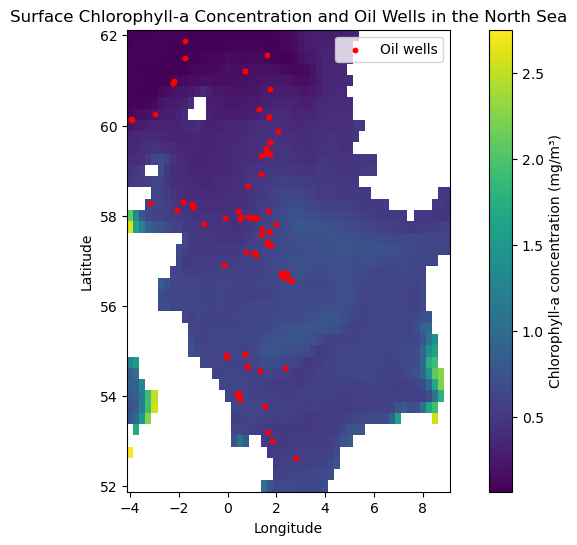

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load oil well CSV
oil_df = pd.read_csv("./UKCS_offshore_petroleum_exploration_and_appraisal_well_results_(ED50)_-1618047620638058084.csv")

# Create point geometry from x and y
oil_rigs = gpd.GeoDataFrame(
    oil_df,
    geometry=gpd.points_from_xy(oil_df["x"], oil_df["y"]),
    crs="EPSG:4326"
)

# Select CHLA surface layer
surface_chl = data["chl"].isel(time=0, depth=0)

# Clip CHLA to North Sea
north_sea_chl = surface_chl.sel(
    longitude=slice(-4, 9),
    latitude=slice(52, 62)
)

# Clip oil rigs to North Sea
oil_rigs_ns = oil_rigs.cx[-4:9, 52:62]

# Plot CHLA + oil rigs
fig, ax = plt.subplots(figsize=(10, 6))

north_sea_chl.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Chlorophyll-a concentration (mg/m³)"}
)

oil_rigs_ns.plot(
    ax=ax,
    color="red",
    markersize=10,
    label="Oil wells"
)

ax.set_title("Surface Chlorophyll-a Concentration and Oil Wells in the North Sea")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.show()

**Figure 3.** *overlays offshore oil well locations with surface chlorophyll-a concentrations in the North Sea during January 2025.*

Oil wells are primarily concentrated in the central
North Sea, where chlorophyll-a concentrations appear
to remain generally low to moderate. Higher
chlorophyll-a concentrations are more commonly
observed closer to coastal regions, potentially
reflecting increased nutrient availability and coastal
mixing processes.

Although several oil well locations overlap with areas
of moderate chlorophyll-a concentration, this figure
alone cannot determine a direct causal relationship
between offshore oil infrastructure and phytoplankton
distribution. Further spatial and statistical analyses
would be required to evaluate these relationships.

**GenAI Declaration Statement**
Generative AI tools were used in this assignment for grammar checking, language refinement, and coding support. All analysis, interpretation, spatial outputs, and final decisions were independently reviewed and edited by the authors.

**Reference**

Alvarez-Fernandez, S., Lindeboom, H., & Meesters, E. (2012). Temporal changes in plankton of the North Sea: community shifts and environmental drivers. Marine Ecology Progress Series, 462, 21–38.    https://doi.org/10.3354/meps09817 

Boyer, J. N., Kelble, C. R., Ortner, P. B., & Rudnick, D. T. (2009). Phytoplankton bloom status: Chlorophyll a biomass as an indicator of water quality condition in the southern estuaries of Florida, USA. Ecological Indicators, 9(6 Suppl.), S56–S67. https://doi.org/10.1016/j.ecolind.2008.11.013

Copernicus. (2026). Global Ocean Biogeochemistry Analysis and Forecast [Map]. Copernicus Marine Service. https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_BGC_001_028/description 

Davenport, J. (1982). Oil and planktonic ecosystems. Philosophical Transactions of the Royal Society of London. B, Biological Sciences, 297(1087), 369–384. https://doi.org/10.1098/rstb.1982.0048 

Falkowski, P. G. (1994). The role of phytoplankton photosynthesis in global biogeochemical cycles. Photosynthesis Research, 39(3), 235–258. https://doi.org/10.1007/BF00014586 

González, J., Fernández, E., & Figueiras, F. G. (2022). Assessing the effect of oil spills on the dynamics of the microbial plankton community using a NPZD model. Estuarine, Coastal and Shelf Science, 265, 107734. https://doi.org/10.1016/j.ecss.2021.107734 

Kelble, C. R., Ortner, P. B., Hitchcock, G. L., & Boyer, J. N. (2005). Attenuation of photosynthetically available radiation (PAR) in Florida Bay: Potential for light limitation of primary producers. Estuaries, 28(4), 560–571. https://doi.org/10.1007/bf02696067

NSTA. (2025). UKCS offshore petroleum exploration and appraisal wellbore results (ED50). Arcgis.com. https://open-data-ukcs-transition.hub.arcgis.com/datasets/10d5c0537788403996574085858f0ac2_2/explore 

Silori, S., Desmit, X., & Fettweis, M. (2025). Spatio-temporal variation in particulate and dissolved organic matter dynamics in the southern North Sea. Biogeochemistry, 168(6). https://doi.org/10.1007/s10533-025-01288-7 

Watson, J. M. (1975). North Sea--Major Petroleum Province. AAPG Bulletin, 59(7). https://doi.org/10.1306/83d91f33-16c7-11d7-8645000102c1865d 
